# 02 — Main Face Detection Application

Dit notebook is de **hoofdapplicatie** van het project.

## Doel
Het opgeslagen CNN-model gebruiken om gezichten te detecteren in een grotere afbeelding via:
1. sliding window
2. score threshold
3. Non-Maximum Suppression (NMS)

## Verwachte input
- het opgeslagen model uit notebook 01
- een testafbeelding, bijvoorbeeld `test_images/test.jpg`

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

## Configuratie

In [2]:
IMG_SIZE = 64
MODEL_PATH = "models/face_classifier.keras"
TEST_IMAGE_PATH = "test_images/test.jpg"
OUTPUT_IMAGE_PATH = "outputs/detected_faces.jpg"

os.makedirs("outputs", exist_ok=True)

## Model laden

In [3]:
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Model niet gevonden: {MODEL_PATH}. "
        "Train eerst notebook 01."
    )

model = load_model(MODEL_PATH)
print("Model geladen:", MODEL_PATH)

Model geladen: models/face_classifier.keras


c:\Users\Administrateur\Desktop\syntra\datascientist\cursus data\2526_Data_Science\venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Sliding window functie

Deze functie beweegt een venster over de volledige afbeelding.
Elk venster wordt later apart geclassificeerd door het CNN.

In [4]:
def sliding_window(image, step_size, window_size):
    for y in range(0, image.shape[0] - window_size[1] + 1, step_size):
        for x in range(0, image.shape[1] - window_size[0] + 1, step_size):
            yield (x, y, image[y:y + window_size[1], x:x + window_size[0]])

## Non-Maximum Suppression (NMS)

NMS verwijdert overlappende boxes zodat we liefst één goede box per gezicht overhouden.

In [5]:
def nms(boxes, overlap_thresh=0.3):
    if len(boxes) == 0:
        return np.array([])

    boxes = np.array(boxes, dtype=float)

    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]
    scores = boxes[:, 4]

    areas = (x2 - x1 + 1) * (y2 - y1 + 1)
    idxs = np.argsort(scores)

    picked = []

    while len(idxs) > 0:
        last = idxs[-1]
        picked.append(last)

        xx1 = np.maximum(x1[last], x1[idxs[:-1]])
        yy1 = np.maximum(y1[last], y1[idxs[:-1]])
        xx2 = np.minimum(x2[last], x2[idxs[:-1]])
        yy2 = np.minimum(y2[last], y2[idxs[:-1]])

        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)

        overlap = (w * h) / areas[idxs[:-1]]

        idxs = np.delete(
            idxs,
            np.concatenate(([len(idxs) - 1], np.where(overlap > overlap_thresh)[0]))
        )

    return boxes[picked]

## Hoofdapplicatie

Deze functie:
- laadt een afbeelding
- genereert sliding windows
- gebruikt het CNN voor classificatie
- bewaart kandidaat-detecties
- past NMS toe
- tekent de finale bounding boxes

In [6]:
def detect_faces(image_path, model, step_size=16, threshold=0.90, overlap_thresh=0.30):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Afbeelding niet gevonden of niet leesbaar: {image_path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    detections = []

    for (x, y, window) in sliding_window(img_bgr, step_size=step_size, window_size=(IMG_SIZE, IMG_SIZE)):
        if window.shape[0] != IMG_SIZE or window.shape[1] != IMG_SIZE:
            continue

        window_rgb = cv2.cvtColor(window, cv2.COLOR_BGR2RGB)
        window_norm = window_rgb / 255.0
        window_input = np.expand_dims(window_norm, axis=0)

        pred = float(model.predict(window_input, verbose=0)[0][0])

        if pred > threshold:
            detections.append([x, y, x + IMG_SIZE, y + IMG_SIZE, pred])

    final_boxes = nms(detections, overlap_thresh=overlap_thresh)

    result = img_rgb.copy()
    if len(final_boxes) > 0:
        for (x1, y1, x2, y2, score) in final_boxes:
            cv2.rectangle(result, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
            cv2.putText(
                result,
                f"{score:.2f}",
                (int(x1), max(int(y1) - 5, 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                1
            )

    return img_rgb, detections, final_boxes, result

## Applicatie uitvoeren

In [7]:
original_img, raw_detections, final_boxes, result_img = detect_faces(
    TEST_IMAGE_PATH,
    model=model,
    step_size=16,
    threshold=0.90,
    overlap_thresh=0.10
)

print("Aantal ruwe detecties:", len(raw_detections))
print("Aantal finale detecties na NMS:", len(final_boxes))

Aantal ruwe detecties: 679
Aantal finale detecties na NMS: 58


## Resultaat tonen

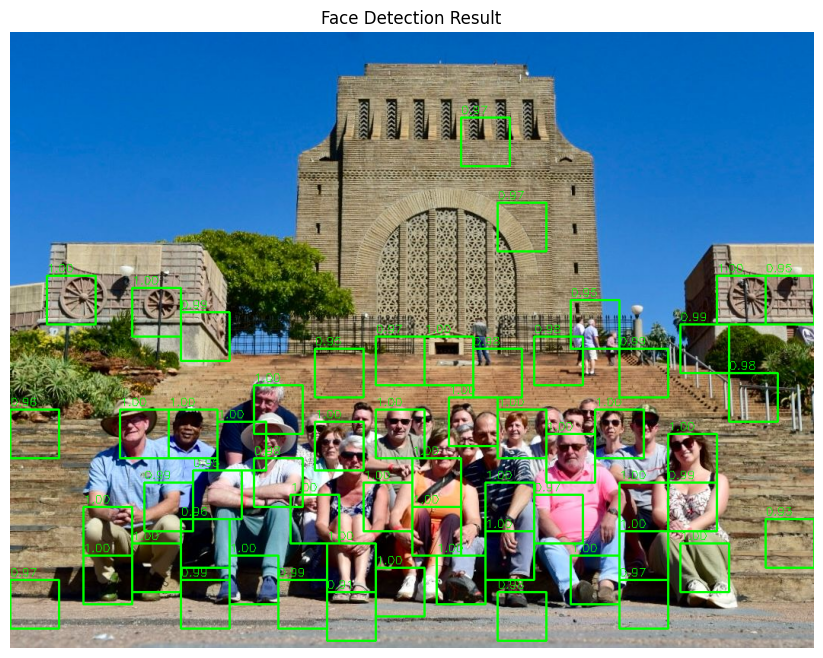

In [8]:
plt.figure(figsize=(12, 8))
plt.imshow(result_img)
plt.title("Face Detection Result")
plt.axis("off")
plt.show()

## Resultaat opslaan

In [9]:
cv2.imwrite(OUTPUT_IMAGE_PATH, cv2.cvtColor(result_img, cv2.COLOR_RGB2BGR))
print("Output opgeslagen in:", OUTPUT_IMAGE_PATH)

Output opgeslagen in: outputs/detected_faces.jpg


## Besluit

Dit notebook is de **pipeline application**:
- het gebruikt een getraind model
- het voert end-to-end detectie uit
- het visualiseert en bewaart het eindresultaat
